In [1]:
# Imports, seeds, device
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device (CUDA, Apple MPS, or CPU)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Using device:", DEVICE)

# Global config
BATCH_TRAIN = 128
BATCH_TEST = 256
EPOCHS = 5  # keep small for demo; adjust if needed
TRAIN_SUBSET = 20000  # set to None for full training set
DATA_ROOT = os.path.join(os.getcwd(), "data")

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

# Temperature for Energy score
ENERGY_T = 1.0

# Percentile for ReAct clipping
REACT_PERCENTILE = 0.95


Using device: mps


In [9]:
# Data: CIFAR-10 (ID) and MNIST (OOD)
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# MNIST -> 32x32 and 3 channels using built-in, picklable transforms (avoid lambda for DataLoader workers)
transform_mnist = transforms.Compose([
    transforms.Resize(32),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Datasets
cifar_train = datasets.CIFAR10(root=DATA_ROOT, train=True, download=True, transform=transform_train)
cifar_test = datasets.CIFAR10(root=DATA_ROOT, train=False, download=True, transform=transform_test)
mnist_test = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=transform_mnist)

# Optional training subset for speed
if TRAIN_SUBSET is not None:
    idx = np.random.RandomState(SEED).permutation(len(cifar_train))[:TRAIN_SUBSET]
    cifar_train = Subset(cifar_train, idx)

# Loaders
train_loader = DataLoader(cifar_train, batch_size=BATCH_TRAIN, shuffle=True, num_workers=2, pin_memory=True)
id_test_loader = DataLoader(cifar_test, batch_size=BATCH_TEST, shuffle=False, num_workers=2, pin_memory=True)
ood_test_loader = DataLoader(mnist_test, batch_size=BATCH_TEST, shuffle=False, num_workers=2, pin_memory=True)

len_train = len(cifar_train) if isinstance(cifar_train, Subset) else len(cifar_train)
print(f"Train samples: {len_train}; CIFAR-10 test: {len(cifar_test)}; MNIST test (OOD): {len(mnist_test)}")

Train samples: 20000; CIFAR-10 test: 10000; MNIST test (OOD): 10000


In [3]:
# Small CNN with dropout and penultimate features for ReAct
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(p=dropout_p)
        # After 3 pools: 32->16->8->4, channels 128 => 128*4*4 = 2048
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.classifier = nn.Linear(256, num_classes)

    def forward_features(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.drop(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = self.drop(x)
        x = self.pool(F.relu(self.conv3(x)))
        x = self.drop(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return x  # penultimate features (before final classifier)

    def logits_from_features(self, feats):
        return self.classifier(feats)

    def forward(self, x):
        feats = self.forward_features(x)
        logits = self.logits_from_features(feats)
        return logits

model = SmallCNN().to(DEVICE)
print(model)

# Smoke test: one forward pass and MSP on a single batch
images, _ = next(iter(id_test_loader))
images = images.to(DEVICE)
with torch.no_grad():
    logits = model(images)
    probs = F.softmax(logits, dim=1)
    msp = probs.max(dim=1).values
print("Smoke test: logits shape:", logits.shape, "MSP shape:", msp.shape)

SmallCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (classifier): Linear(in_features=256, out_features=10, bias=True)
)


/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Smoke test: logits shape: torch.Size([256, 10]) MSP shape: torch.Size([256])


In [4]:
# Train simple CNN on CIFAR-10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs+1):
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        print(f"Epoch {ep}/{epochs} - loss: {running_loss/total:.4f} - acc: {correct/total:.3f}")

train(model, train_loader, epochs=EPOCHS)


Epoch 1/5 - loss: 1.7619 - acc: 0.352
Epoch 2/5 - loss: 1.3905 - acc: 0.491
Epoch 3/5 - loss: 1.2468 - acc: 0.551
Epoch 4/5 - loss: 1.1260 - acc: 0.596
Epoch 5/5 - loss: 1.0448 - acc: 0.629


In [5]:
# Compute ReAct clipping threshold from ID training features

def compute_react_clip_threshold(model, loader, percentile=REACT_PERCENTILE, max_batches=None):
    model.eval()
    feats_all = []
    with torch.no_grad():
        for b_idx, (images, _) in enumerate(loader):
            images = images.to(DEVICE)
            feats = model.forward_features(images)
            feats_all.append(feats.detach().cpu())
            if max_batches is not None and (b_idx + 1) >= max_batches:
                break
    feats_all = torch.cat(feats_all, dim=0)  # [N, D]
    clip_value = torch.quantile(feats_all.reshape(-1), torch.tensor(percentile)).item()
    return clip_value

react_clip_value = compute_react_clip_threshold(model, train_loader, percentile=REACT_PERCENTILE, max_batches=100)
print(f"ReAct clip value (percentile={REACT_PERCENTILE}): {react_clip_value:.4f}")


ReAct clip value (percentile=0.95): 2.7179


In [6]:
# OOD scoring functions: MSP, MC Dropout entropy, ReAct Energy

def msp_scores(model, loader):
    model.eval()
    scores = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(DEVICE)
            logits = model(images)
            probs = F.softmax(logits, dim=1)
            msp = probs.max(dim=1).values
            scores.append((-msp).cpu())  # higher => more OOD
    return torch.cat(scores).numpy()


def mc_dropout_entropy_scores(model, loader, n_passes=20):
    scores = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(DEVICE)
            # Enable dropout: train mode (no BN in this model)
            model.train()
            probs_sum = torch.zeros(images.size(0), 10, device=DEVICE)
            for _ in range(n_passes):
                logits = model(images)
                probs_sum += F.softmax(logits, dim=1)
            probs_avg = probs_sum / n_passes
            # Predictive entropy
            entropy = -(probs_avg * (probs_avg.clamp_min(1e-8)).log()).sum(dim=1)
            scores.append(entropy.cpu())  # higher => more OOD
    # Restore eval mode
    model.eval()
    return torch.cat(scores).numpy()


def react_energy_scores(model, loader, clip_value, T=ENERGY_T):
    model.eval()
    scores = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(DEVICE)
            feats = model.forward_features(images)
            feats_clipped = torch.clamp(feats, max=clip_value)
            logits = model.logits_from_features(feats_clipped)
            energy = -T * torch.logsumexp(logits / T, dim=1)
            scores.append(energy.cpu())  # higher => more OOD
    return torch.cat(scores).numpy()


In [10]:
# Metrics: AUROC, AUPR (Out/In), FPR@95%TPR

def compute_auroc(id_scores, ood_scores):
    y = np.concatenate([np.zeros_like(id_scores), np.ones_like(ood_scores)])
    s = np.concatenate([id_scores, ood_scores])
    return roc_auc_score(y, s)


def compute_aupr_out(id_scores, ood_scores):
    y = np.concatenate([np.zeros_like(id_scores), np.ones_like(ood_scores)])
    s = np.concatenate([id_scores, ood_scores])
    return average_precision_score(y, s)  # positive class = OOD


def compute_aupr_in(id_scores, ood_scores):
    y_in = np.concatenate([np.ones_like(id_scores), np.zeros_like(ood_scores)])
    s = np.concatenate([id_scores, ood_scores])
    return average_precision_score(y_in, -s)  # higher => ID


def fpr_at_95_tpr(id_scores, ood_scores):
    # higher score => more OOD; ID predicted as ID when score <= threshold
    tpr_target = 0.95
    id_sorted = np.sort(id_scores)
    threshold = id_sorted[int(np.ceil(tpr_target * len(id_sorted))) - 1]
    fpr = np.mean(ood_scores <= threshold)
    return fpr, threshold


def evaluate_all_methods(model, id_loader, ood_loader, react_clip_value, n_mc_passes=20):
    results = {}

    # MSP
    id_msp = msp_scores(model, id_loader)
    ood_msp = msp_scores(model, ood_loader)
    results['MSP'] = {
        'AUROC': compute_auroc(id_msp, ood_msp),
        'AUPR-Out': compute_aupr_out(id_msp, ood_msp),
        'AUPR-In': compute_aupr_in(id_msp, ood_msp),
        'FPR@95TPR': fpr_at_95_tpr(id_msp, ood_msp)[0],
    }

    # MC Dropout (predictive entropy)
    id_mc = mc_dropout_entropy_scores(model, id_loader, n_passes=n_mc_passes)
    ood_mc = mc_dropout_entropy_scores(model, ood_loader, n_passes=n_mc_passes)
    results['MC-Dropout'] = {
        'AUROC': compute_auroc(id_mc, ood_mc),
        'AUPR-Out': compute_aupr_out(id_mc, ood_mc),
        'AUPR-In': compute_aupr_in(id_mc, ood_mc),
        'FPR@95TPR': fpr_at_95_tpr(id_mc, ood_mc)[0],
    }

    # ReAct Energy
    id_re = react_energy_scores(model, id_loader, clip_value=react_clip_value, T=ENERGY_T)
    ood_re = react_energy_scores(model, ood_loader, clip_value=react_clip_value, T=ENERGY_T)
    results['ReAct-Energy'] = {
        'AUROC': compute_auroc(id_re, ood_re),
        'AUPR-Out': compute_aupr_out(id_re, ood_re),
        'AUPR-In': compute_aupr_in(id_re, ood_re),
        'FPR@95TPR': fpr_at_95_tpr(id_re, ood_re)[0],
    }

    return results, {'MSP': (id_msp, ood_msp), 'MC-Dropout': (id_mc, ood_mc), 'ReAct-Energy': (id_re, ood_re)}

results, raw_scores = evaluate_all_methods(model, id_test_loader, ood_test_loader, react_clip_value, n_mc_passes=20)
print("\nMetrics (CIFAR-10 = ID, MNIST = OOD):")
for m, vals in results.items():
    print(f"{m:>12} | AUROC: {vals['AUROC']:.4f} | AUPR-Out: {vals['AUPR-Out']:.4f} | AUPR-In: {vals['AUPR-In']:.4f} | FPR@95TPR: {vals['FPR@95TPR']:.4f}")


/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/ilyakisel


Metrics (CIFAR-10 = ID, MNIST = OOD):
         MSP | AUROC: 0.6548 | AUPR-Out: 0.5861 | AUPR-In: 0.6972 | FPR@95TPR: 0.9426
  MC-Dropout | AUROC: 0.6618 | AUPR-Out: 0.5820 | AUPR-In: 0.7206 | FPR@95TPR: 0.9526
ReAct-Energy | AUROC: 0.7573 | AUPR-Out: 0.6761 | AUPR-In: 0.8161 | FPR@95TPR: 0.8939


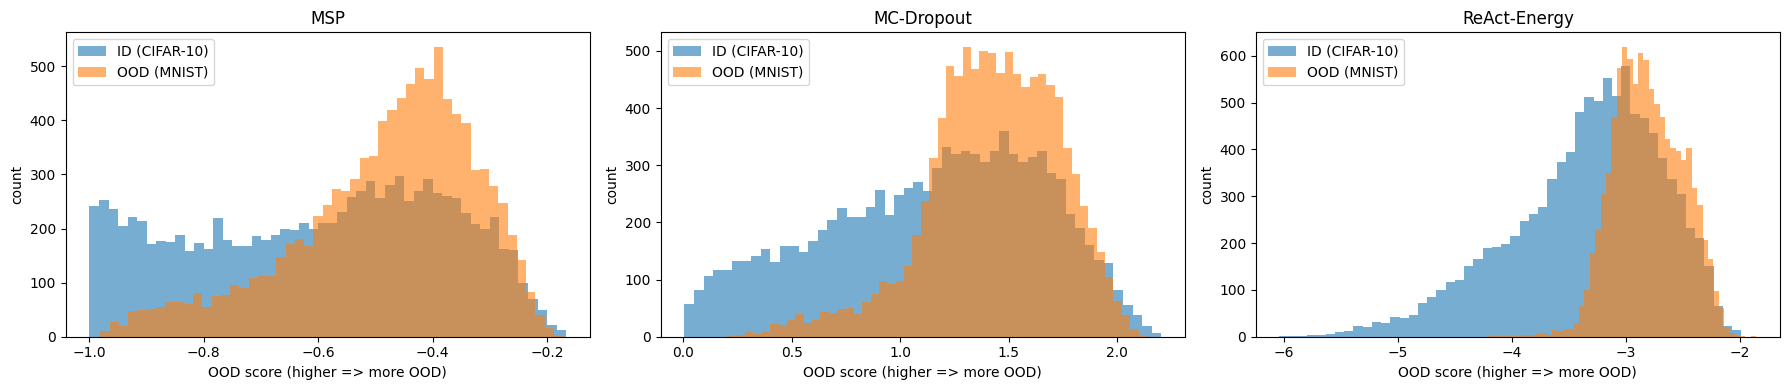

In [11]:
# Visualize score distributions (ID vs OOD)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
methods = ['MSP', 'MC-Dropout', 'ReAct-Energy']
for ax, m in zip(axes, methods):
    id_scores, ood_scores = raw_scores[m]
    ax.hist(id_scores, bins=50, alpha=0.6, label='ID (CIFAR-10)')
    ax.hist(ood_scores, bins=50, alpha=0.6, label='OOD (MNIST)')
    ax.set_title(m)
    ax.set_xlabel('OOD score (higher => more OOD)')
    ax.set_ylabel('count')
    ax.legend()
plt.tight_layout()
plt.show()
